In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams["figure.figsize"] = (10, 5)



In [9]:
# pandas is already imported in another cell, so no import is needed hered
df = pd.read_csv('ecommerce_orders_dataset.csv')
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 30000 non-null  int64  
 1   Customer_ID              30000 non-null  object 
 2   Order_Date               30000 non-null  object 
 3   Year                     30000 non-null  int64  
 4   Month                    30000 non-null  int64  
 5   Day                      30000 non-null  int64  
 6   Day_Of_Week              30000 non-null  object 
 7   Quarter                  30000 non-null  int64  
 8   Customer_Age             30000 non-null  int64  
 9   Customer_Gender          30000 non-null  object 
 10  Country                  30000 non-null  object 
 11  City                     30000 non-null  object 
 12  Customer_Segment         30000 non-null  object 
 13  Product_ID               30000 non-null  object 
 14  Product_Category      

In [11]:
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [12]:
df.tail()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
29995,603016,CUST006407,2026-12-31,2026,12,31,Thursday,4,28,Female,...,7,Delivered,No,4.4,4656.30,36.51,118.72,Winter,Yes,No
29996,615920,CUST003743,2026-12-31,2026,12,31,Thursday,4,49,Female,...,7,Delivered,No,4.6,3748.59,15.93,31.71,Winter,No,No
29997,603150,CUST005027,2026-12-31,2026,12,31,Thursday,4,41,Male,...,8,Shipped,No,4.1,1726.84,26.93,27.46,Winter,Yes,No
29998,626020,CUST008716,2026-12-31,2026,12,31,Thursday,4,38,Male,...,3,Delivered,No,3.8,2519.08,11.30,29.61,Winter,Yes,No
29999,609440,CUST009000,2026-12-31,2026,12,31,Thursday,4,18,Male,...,4,Shipped,No,3.4,2238.12,39.60,62.87,Winter,Yes,No


In [13]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
print(f"Date Range: {df['Order_Date'].min()} to {df['Order_Date'].max()}")


Date Range: 2023-01-01 00:00:00 to 2026-12-31 00:00:00


In [14]:
missing  = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df =pd.DataFrame({'missing_Count': missing, 'missing_%': missing_pct})
missing_df[missing_df['missing_Count'] > 0]


,missing_Count,missing_%


In [15]:
print(f"Duplicate Order_IDs: {df['Order_ID'].duplicated().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

Duplicate Order_IDs: 0
Total Duplicate Rows: 0


In [16]:
df.describe()

,Order_ID,Order_Date,Year,Month,Day,Quarter,Customer_Age,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Shipping_Cost,Tax_Amount,Order_Amount,Delivery_Days,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount
count,30000.000000,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,615000.500000,2024-12-29 10:37:23.520000,2024.494700,6.531500,15.723600,2.507000,36.370300,126.820148,3.080667,12.618667,49.432742,10.316779,29.143818,379.001466,4.436667,4.047990,4372.340178,21.969056,73.863876
min,600001.000000,2023-01-01 00:00:00,2023.000000,1.000000,1.000000,1.000000,18.000000,3.840000,1.000000,0.000000,0.000000,0.000000,0.260000,6.670000,0.000000,1.000000,20.000000,3.000000,0.270000
25%,607500.750000,2023-12-27 18:00:00,2023.000000,4.000000,8.000000,2.000000,28.000000,29.880000,2.000000,0.000000,0.000000,6.020000,5.270000,82.947500,3.000000,3.600000,1029.637500,15.680000,16.640000
50%,615000.500000,2024-12-30 00:00:00,2024.000000,7.000000,16.000000,3.000000,36.000000,60.670000,3.000000,10.000000,13.470000,9.000000,12.065000,171.030000,4.000000,4.100000,2073.365000,21.870000,36.995000
75%,622500.250000,2025-12-29 00:00:00,2025.000000,10.000000,23.000000,4.000000,44.000000,128.572500,4.000000,20.000000,44.822500,14.220000,29.442500,388.190000,6.000000,4.600000,4482.105000,28.180000,82.125000
max,630000.000000,2026-12-31 00:00:00,2026.000000,12.000000,31.000000,4.000000,75.000000,1940.000000,11.000000,40.000000,2623.900000,32.600000,1043.160000,10314.270000,13.000000,5.000000,50000.000000,56.610000,2480.540000
std,8660.398374,NaN,1.118815,3.460955,8.779714,1.118806,11.315534,172.675272,1.450412,11.085201,114.401634,5.890701,49.562251,585.405554,2.349363,0.686492,6811.029394,9.079134,113.480736


In [17]:
df.describe(include="object")

,Customer_ID,Day_Of_Week,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,...,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Order_Status,Returned,Season,Holiday_Season,High_Value_Order
count,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000,...,30000,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,8683,7,3,10,10,4,2500,8,32,10,...,3,6,4,4,5,5,2,4,2,2
top,CUST000031,Monday,Female,Canada,London,Returning,PROD02344,Fashion,Men Clothing,Zenith,...,Mobile,Organic Search,Standard,Standard,West,Delivered,No,Summer,No,No
freq,14,4327,14863,3099,3089,11987,27,6092,1591,3099,...,18538,5098,16049,16420,6060,19497,26967,7575,25550,22499


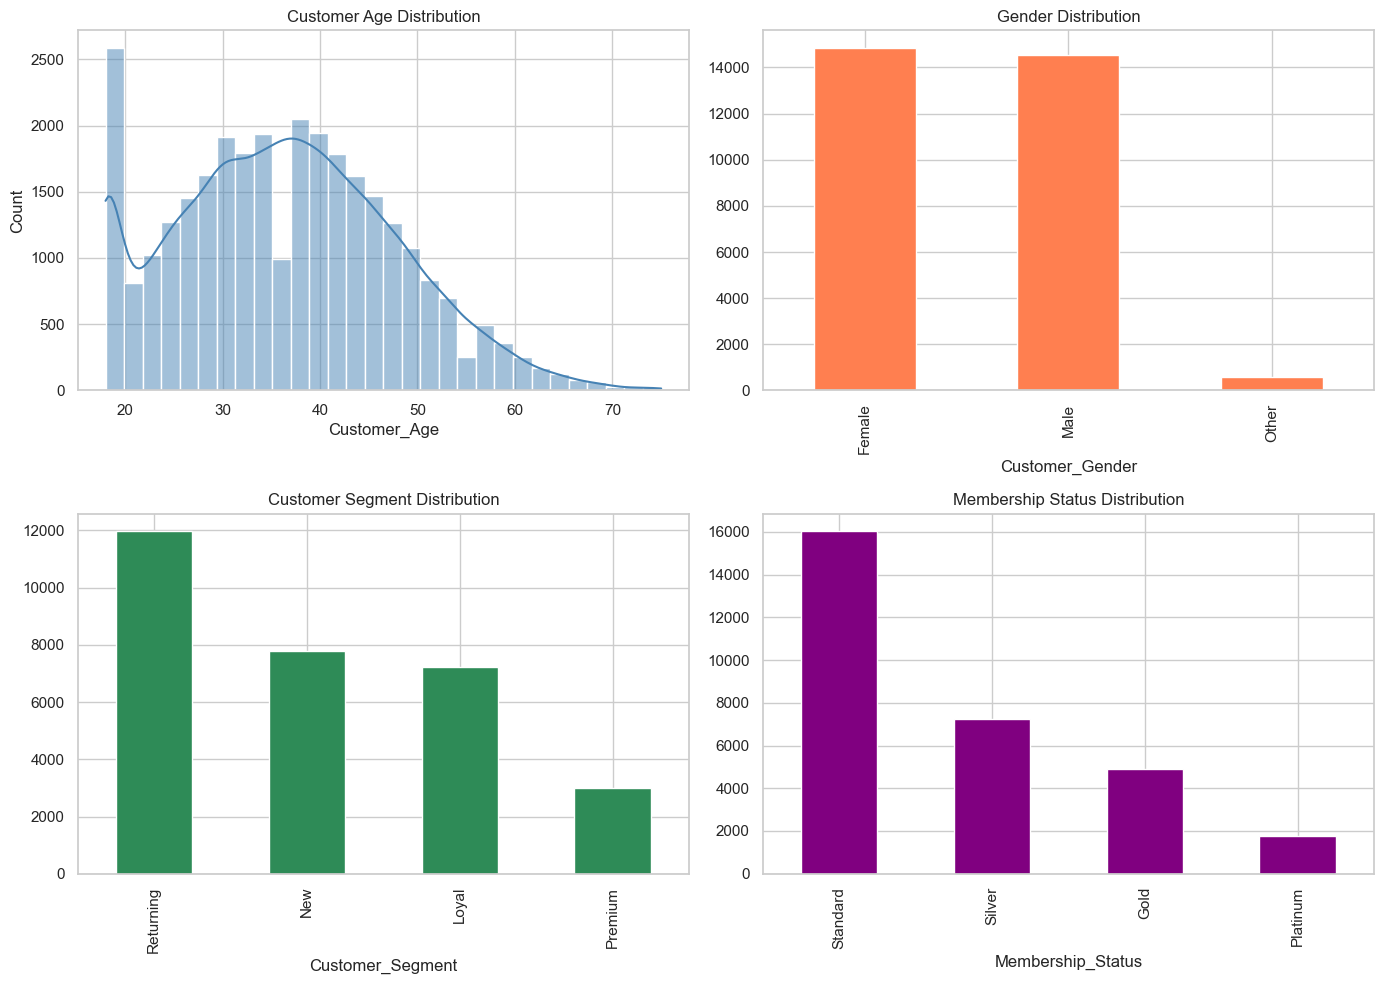

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["Customer_Age"], bins=30, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Customer Age Distribution")

df["Customer_Gender"].value_counts().plot(kind="bar", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Gender Distribution")

df["Customer_Segment"].value_counts().plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Customer Segment Distribution")

df["Membership_Status"].value_counts().plot(kind="bar", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Membership Status Distribution")

plt.tight_layout()
plt.show()

In [19]:
print(f"Average Customer Age: {df['Customer_Age'].mean():.2f} years")
print(f"\nGender Split:\n{df['Customer_Gender'].value_counts()}")

Average Customer Age: 36.37 years

Gender Split:
Customer_Gender
Female    14863
Male      14552
Other       585
Name: count, dtype: int64


In [20]:
labels = ['Young Adult', 'Adult', 'Middle-Aged', 'Senior']
df['age_group'] = pd.qcut(df['Customer_Age'], q=4, labels=labels)
df[['Customer_Age', 'age_group']].head(10)

,Customer_Age,age_group
0,32,Adult
1,50,Senior
2,61,Senior
3,34,Adult
4,37,Middle-Aged
5,32,Adult
6,25,Young Adult
7,38,Middle-Aged
8,48,Senior
9,31,Adult


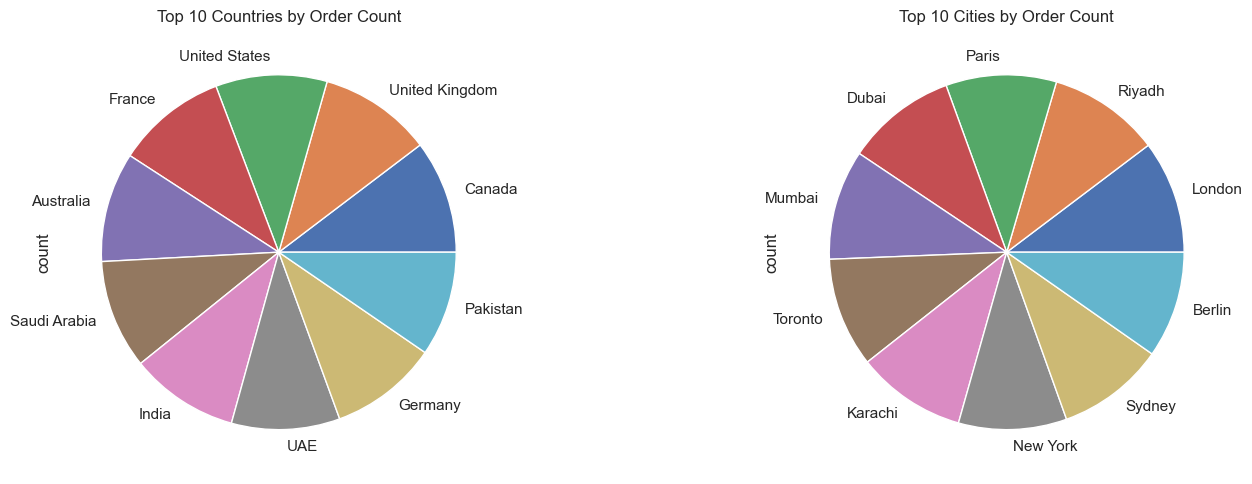

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df["Country"].value_counts().head(10).plot(kind="pie", ax=axes[0], color="darkcyan")
axes[0].set_title("Top 10 Countries by Order Count")

df["City"].value_counts().head(10).plot(kind="pie", ax=axes[1], color="teal")
axes[1].set_title("Top 10 Cities by Order Count")

plt.tight_layout()
plt.show()

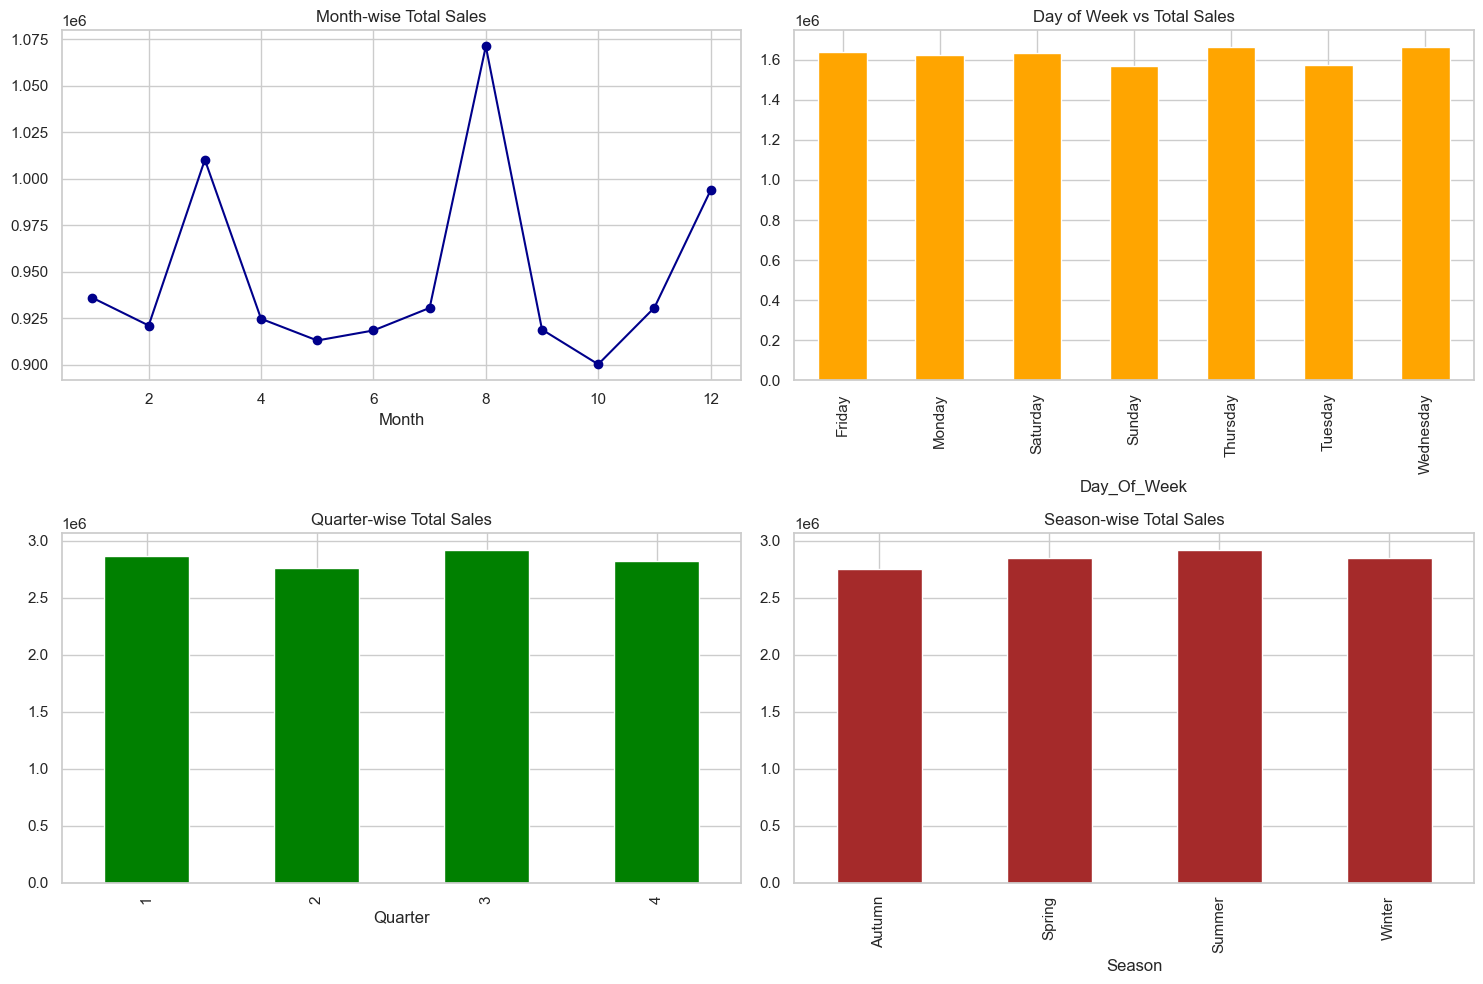

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

monthly_sales = df.groupby("Month")["Order_Amount"].sum().sort_index()
monthly_sales.plot(kind="line", marker="o", ax=axes[0, 0], color="darkblue")
axes[0, 0].set_title("Month-wise Total Sales")

df.groupby("Day_Of_Week")["Order_Amount"].sum().plot(kind="bar", ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Day of Week vs Total Sales")

df.groupby("Quarter")["Order_Amount"].sum().plot(kind="bar", ax=axes[1, 0], color="green")
axes[1, 0].set_title("Quarter-wise Total Sales")

df.groupby("Season")["Order_Amount"].sum().plot(kind="bar", ax=axes[1, 1], color="brown")
axes[1, 1].set_title("Season-wise Total Sales")

plt.tight_layout()
plt.show()

In [23]:
monthly_sales 

Month
1      936076.62
2      921195.64
3     1010299.50
4      924831.93
5      913148.58
6      918539.05
7      930656.68
8     1071268.49
9      919010.17
10     900354.21
11     930805.06
12     993858.06
Name: Order_Amount, dtype: float64

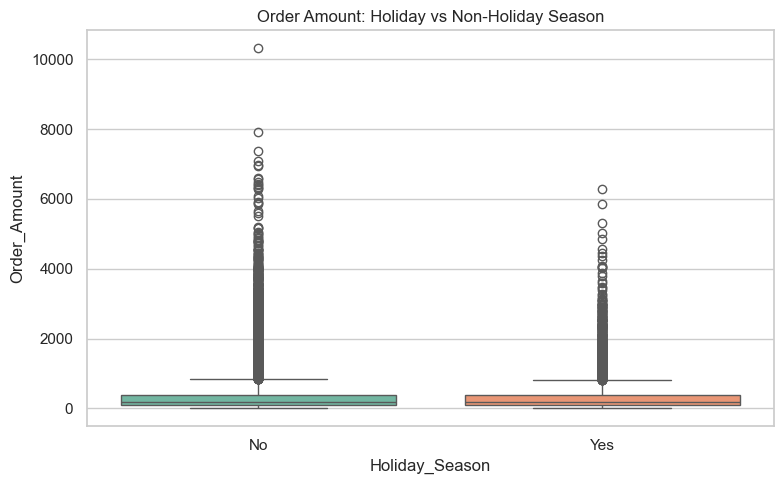

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Holiday_Season", y="Order_Amount", data=df, palette="Set2")
plt.title("Order Amount: Holiday vs Non-Holiday Season")
plt.tight_layout()
plt.show()

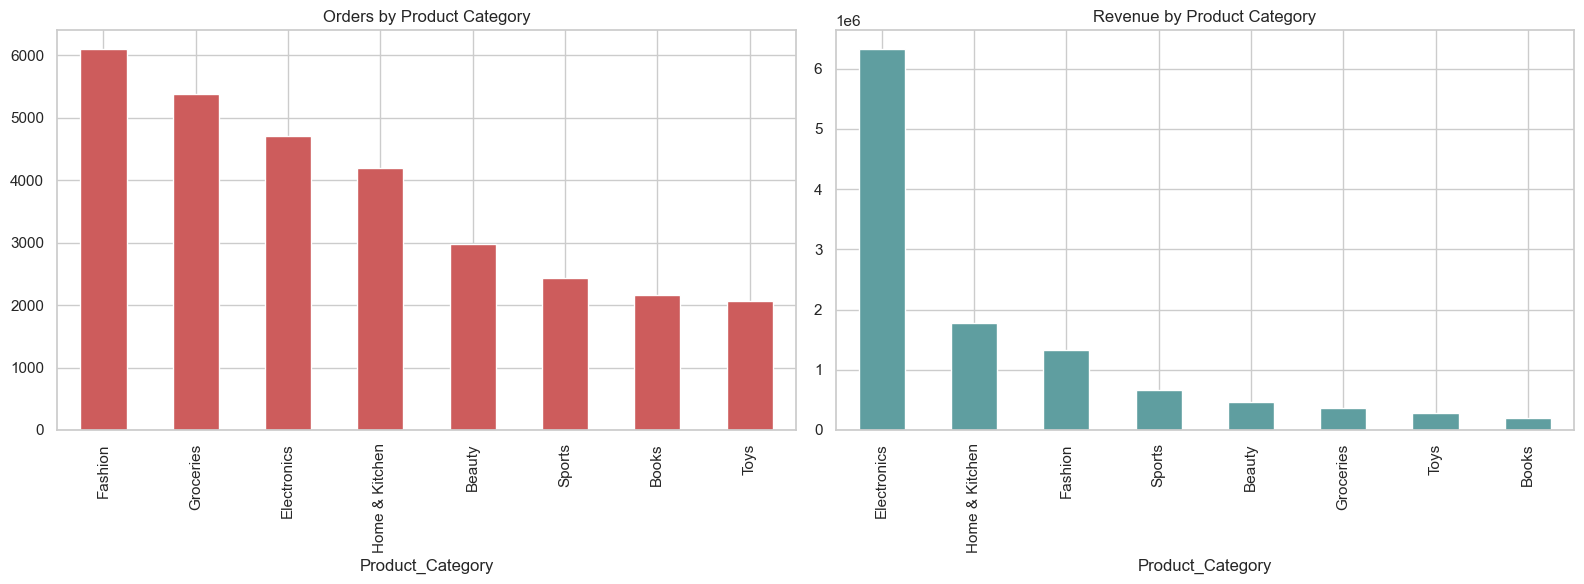

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df["Product_Category"].value_counts().head(10).plot(
    kind="bar", ax=axes[0], color="indianred"
)
axes[0].set_title("Orders by Product Category")

df.groupby("Product_Category")["Order_Amount"].sum().sort_values(ascending=False).head(10).plot(kind="bar", ax=axes[1], color="cadetblue")
axes[1].set_title("Revenue by Product Category")

plt.tight_layout()
plt.show()


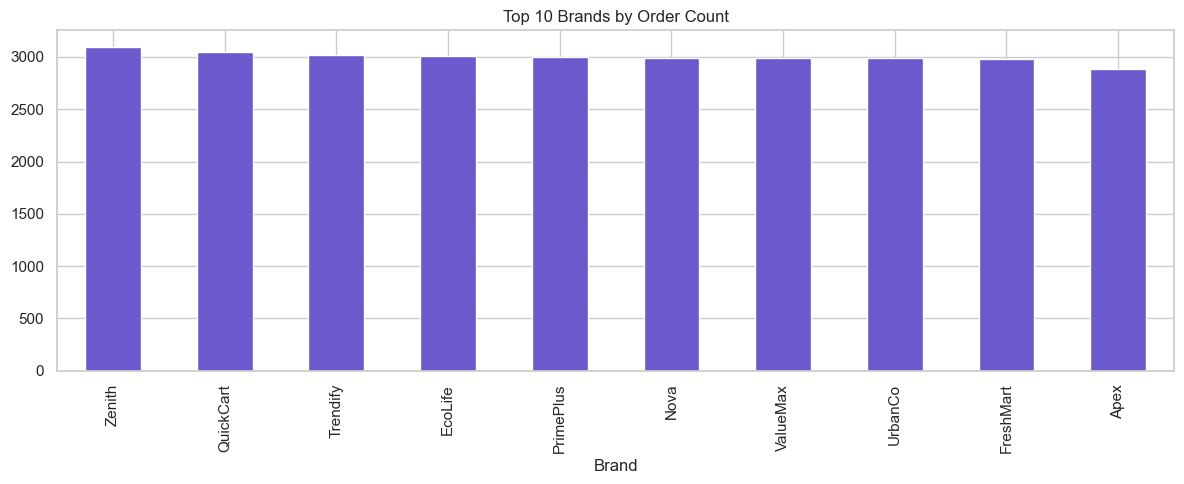

In [26]:
plt.figure(figsize=(12,5))
df["Brand"].value_counts().head(10).plot(kind="bar",color="slateblue")
plt.title("Top 10 Brands by Order Count")
plt.tight_layout()
plt.show()

In [27]:
print(f"Avg Order Amount:{df['Order_Amount'].mean():.2f}")
print(f"Avg Discount%: {df['Discount_Percent'].mean():.2f}%")
print(f"\nCoupon Usage Rate:\n{df['Coupon_Used'].value_counts(normalize=True)*100}")

Avg Order Amount:379.00
Avg Discount%: 12.62%

Coupon Usage Rate:
Coupon_Used
Yes    68.096667
No     31.903333
Name: proportion, dtype: float64


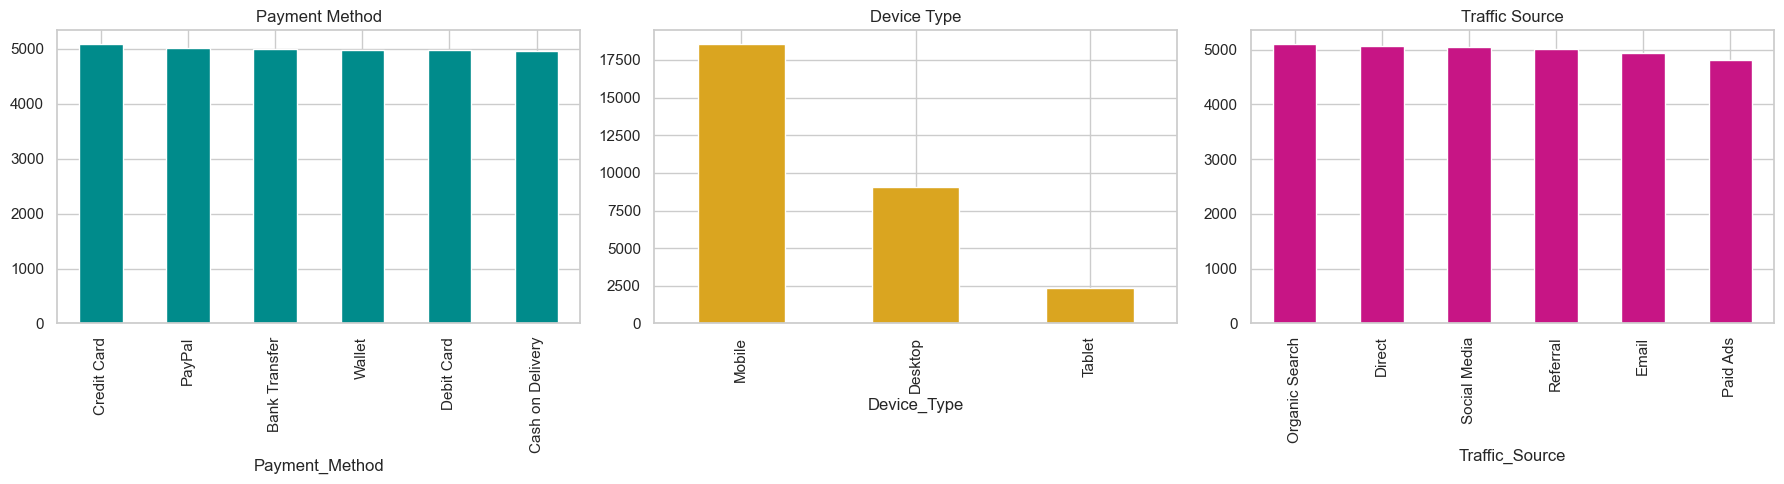

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["Payment_Method"].value_counts().plot(kind="bar", ax=axes[0], color="darkcyan")
axes[0].set_title("Payment Method")

df["Device_Type"].value_counts().plot(kind="bar", ax=axes[1], color="goldenrod")
axes[1].set_title("Device Type")

df["Traffic_Source"].value_counts().plot(kind="bar",ax=axes[2], color="mediumvioletred")
axes[2].set_title("Traffic Source")


plt.tight_layout()
plt.show()


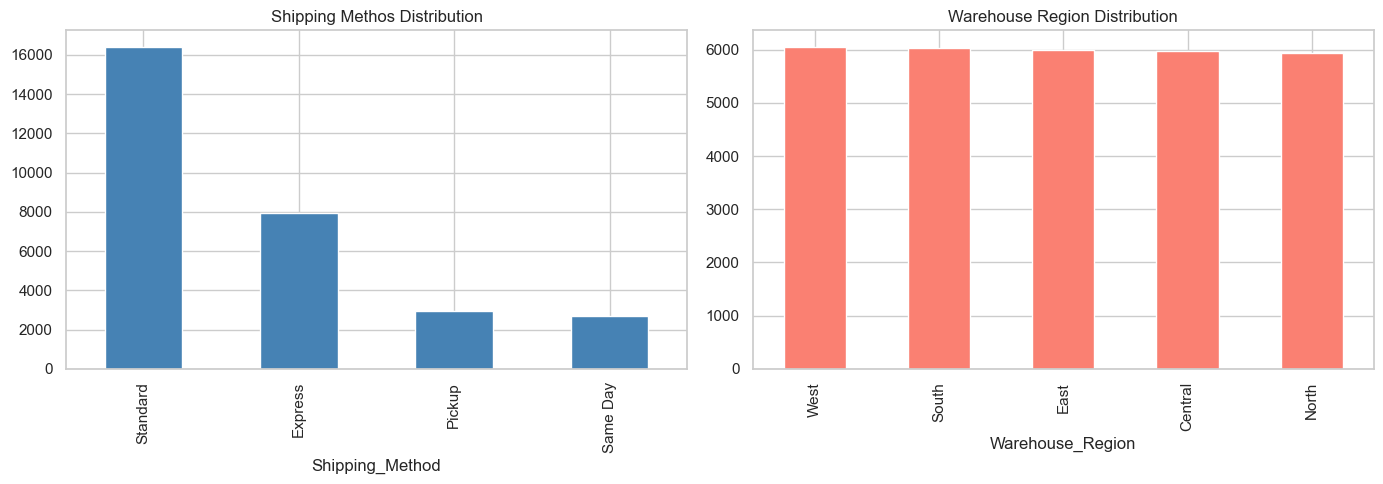

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Shipping_Method"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Shipping Methos Distribution")

df["Warehouse_Region"].value_counts().plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Warehouse Region Distribution")

plt.tight_layout()
plt.show()

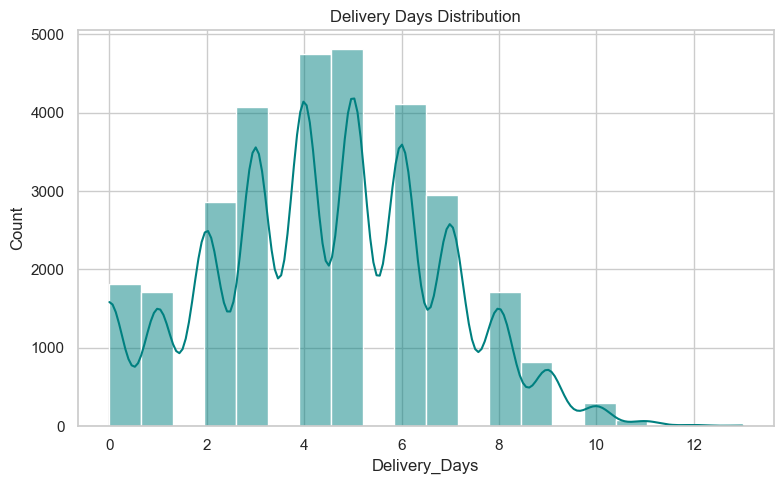

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Delivery_Days"], bins=20, kde=True, color="teal")
plt.title("Delivery Days Distribution")
plt.tight_layout()
plt.show()

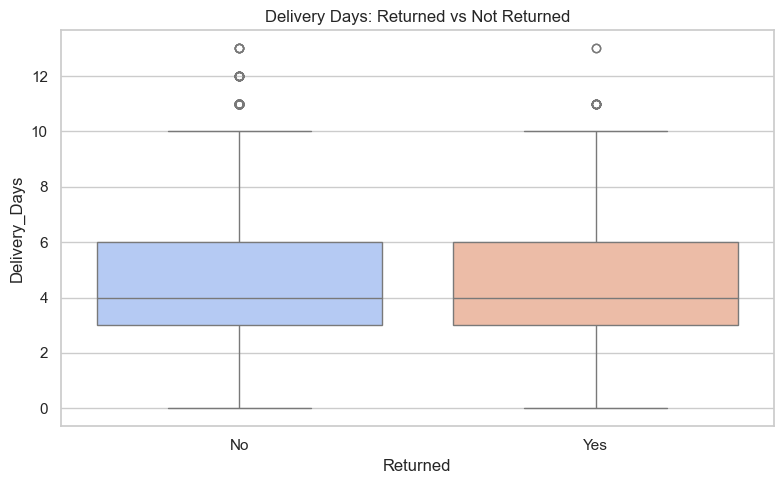

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Returned", y="Delivery_Days", data=df, palette="coolwarm")
plt.title("Delivery Days: Returned vs Not Returned")
plt.tight_layout()
plt.show()

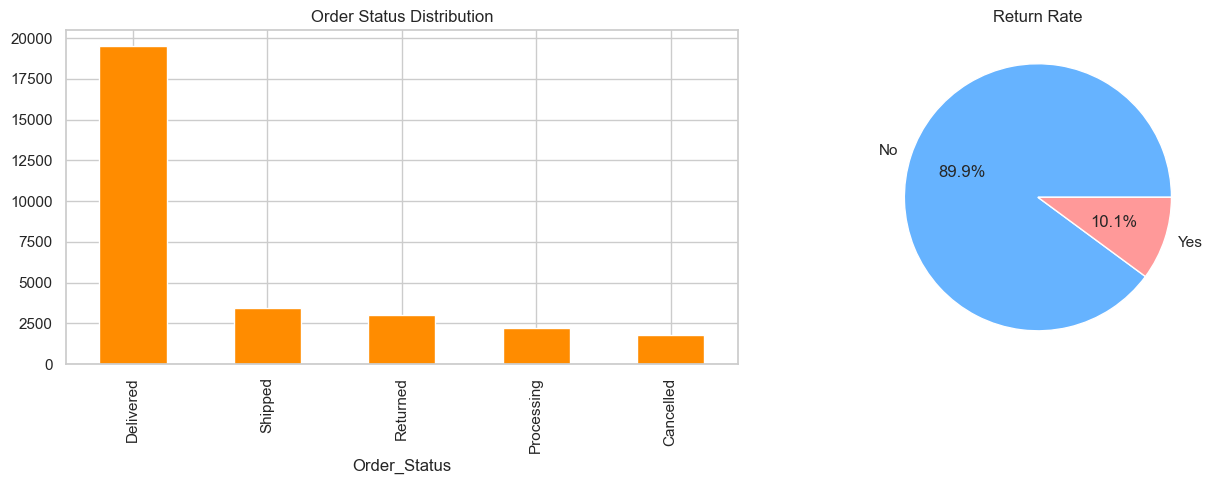

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Order_Status"].value_counts().plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("Order Status Distribution")

df["Returned"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1],
                                    colors=["#66b3ff", "#ff9999"])
axes[1].set_title("Return Rate")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

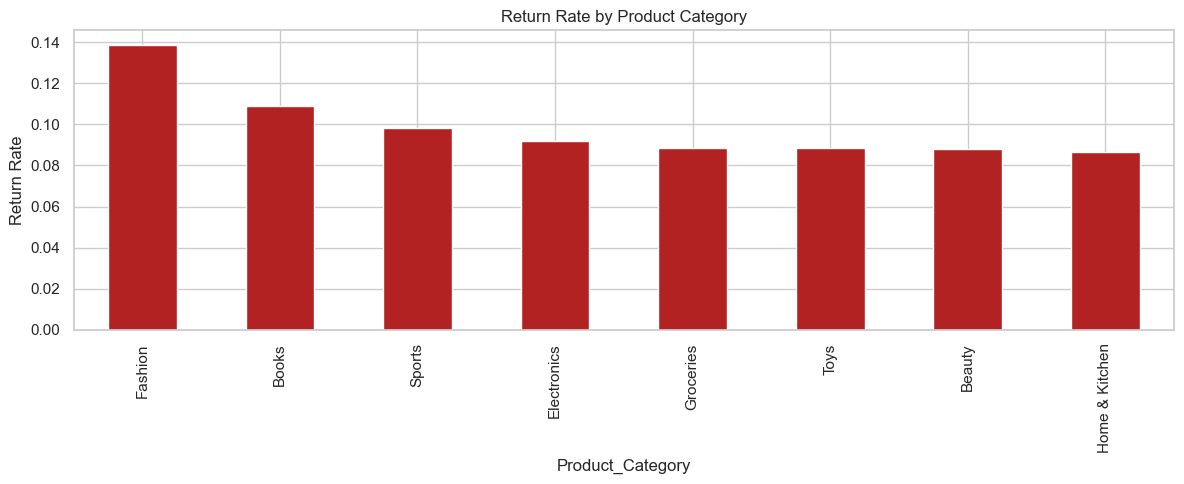

In [37]:
plt.figure(figsize=(12, 5))
return_by_cat = (
    df.groupby("Product_Category")["Returned"]
      .apply(lambda s: (s == "Yes").mean())
      .sort_values(ascending=False)
)
return_by_cat.plot(kind="bar", color="firebrick")
plt.title("Return Rate by Product Category")
plt.ylabel("Return Rate")
plt.tight_layout()
plt.show()

In [38]:
overall_return_rate = (df["Returned"].eq("Yes").mean() * 100)
print(f"Overall Return Rate: {overall_return_rate:.2f}%")

# Show the previously computed category-level return rates
return_by_cat
return_by_cat

Overall Return Rate: 10.11%


Product_Category
Fashion           0.138707
Books             0.109108
Sports            0.097991
Electronics       0.091934
Groceries         0.088290
Toys              0.088264
Beauty            0.087849
Home & Kitchen    0.086552
Name: Returned, dtype: float64

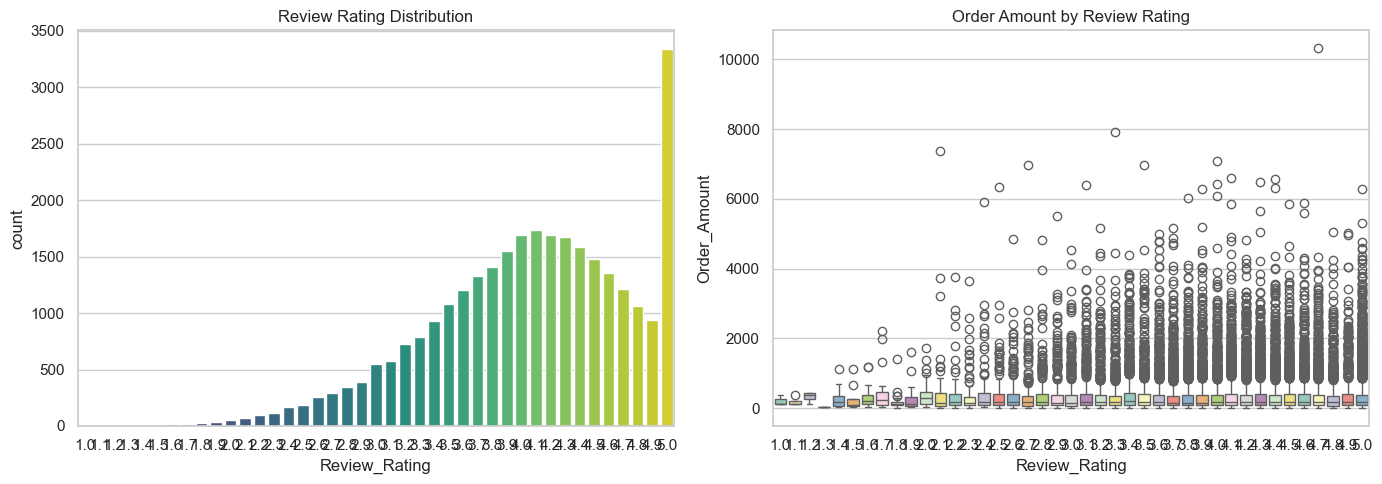

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="Review_Rating", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Review Rating Distribution")

sns.boxplot(x="Review_Rating", y="Order_Amount", data=df, ax=axes[1], palette="Set3")
axes[1].set_title("Order Amount by Review Rating")

plt.tight_layout()
plt.show()

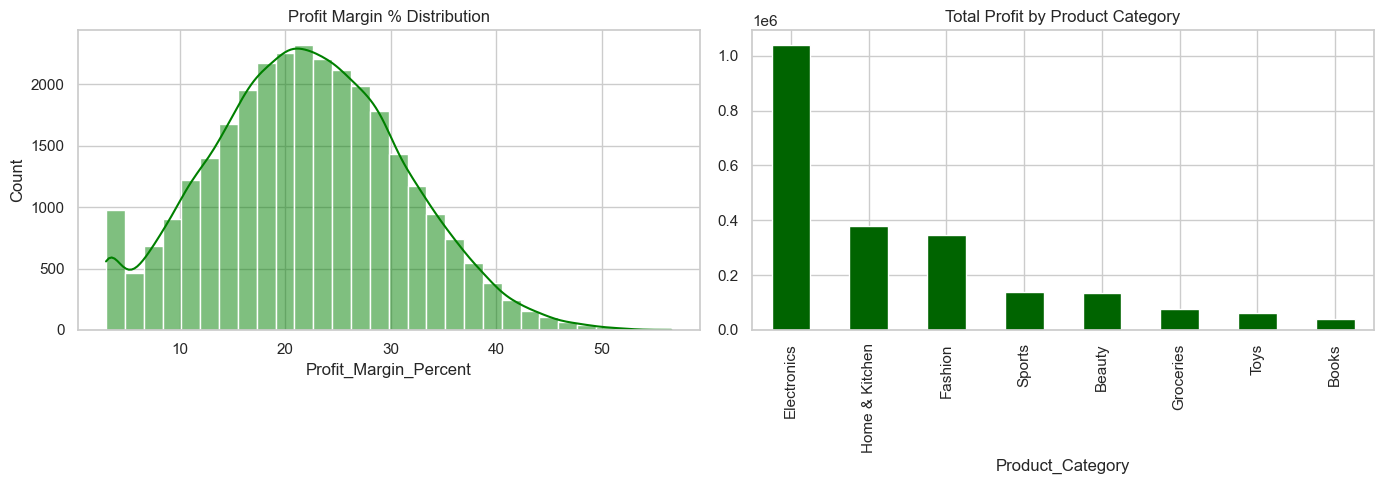

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Profit_Margin_Percent"], bins=30, kde=True, ax=axes[0], color="green")
axes[0].set_title("Profit Margin % Distribution")

df.groupby("Product_Category")["Profit_Amount"].sum().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="darkgreen")
axes[1].set_title("Total Profit by Product Category")

plt.tight_layout()
plt.show()

In [41]:
print(f"Avg Profit Margin: {df['Profit_Margin_Percent'].mean():.2f}%")
print(f"Total Profit: {df['Profit_Amount'].sum():,.2f}")

Avg Profit Margin: 21.97%
Total Profit: 2,215,916.27


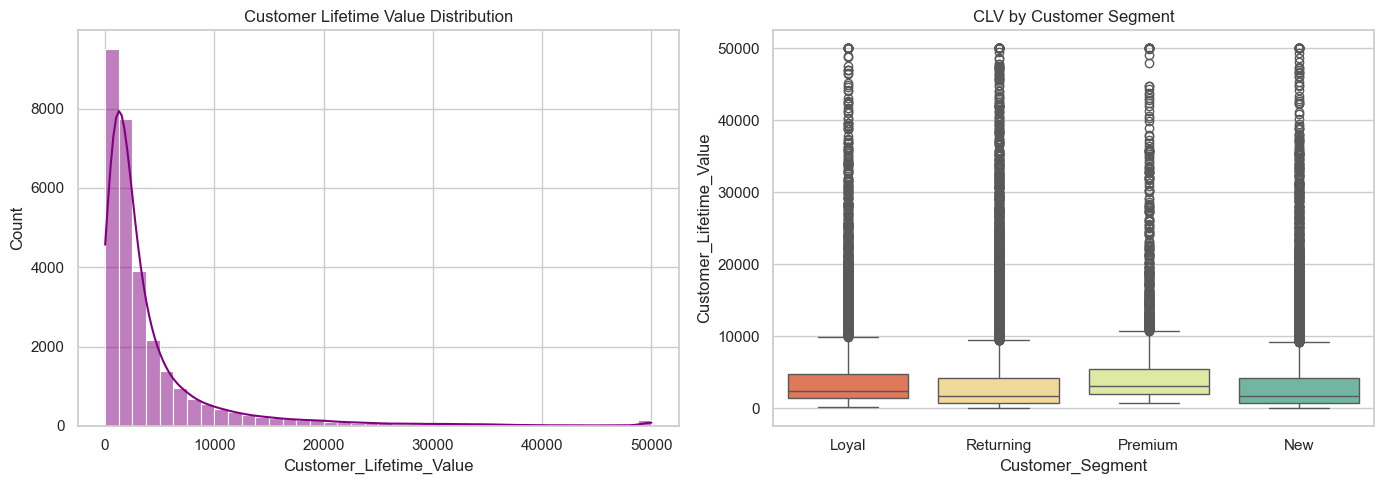

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Customer_Lifetime_Value"], bins=40, kde=True, ax=axes[0], color="purple")
axes[0].set_title("Customer Lifetime Value Distribution")

sns.boxplot(x="Customer_Segment", y="Customer_Lifetime_Value", data=df, ax=axes[1], palette="Spectral")
axes[1].set_title("CLV by Customer Segment")

plt.tight_layout()
plt.show()

In [43]:
print("High Value Order Distribution:")
print(df["High_Value_Order"].value_counts())
print(f"\n% High Value Orders: {df['High_Value_Order'].eq('Yes').mean() * 100:.2f}%")

High Value Order Distribution:
High_Value_Order
No     22499
Yes     7501
Name: count, dtype: int64

% High Value Orders: 25.00%


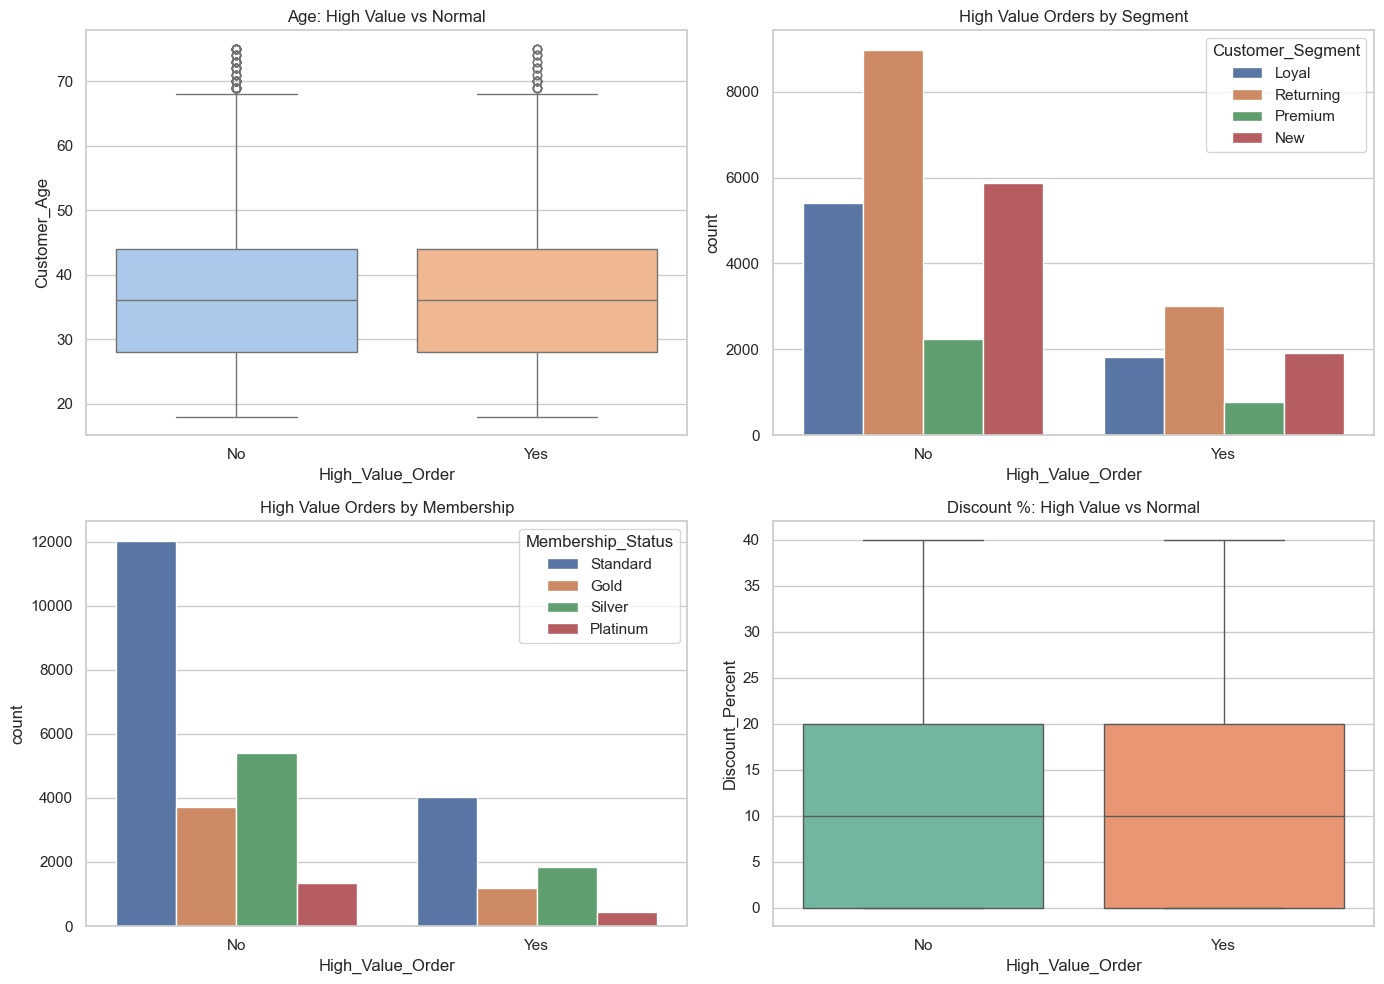

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x="High_Value_Order", y="Customer_Age", data=df, ax=axes[0, 0], palette="pastel")
axes[0, 0].set_title("Age: High Value vs Normal")

sns.countplot(x="High_Value_Order", hue="Customer_Segment", data=df, ax=axes[0, 1])
axes[0, 1].set_title("High Value Orders by Segment")

sns.countplot(x="High_Value_Order", hue="Membership_Status", data=df, ax=axes[1, 0])
axes[1, 0].set_title("High Value Orders by Membership")

sns.boxplot(x="High_Value_Order", y="Discount_Percent", data=df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Discount %: High Value vs Normal")

plt.tight_layout()
plt.show()

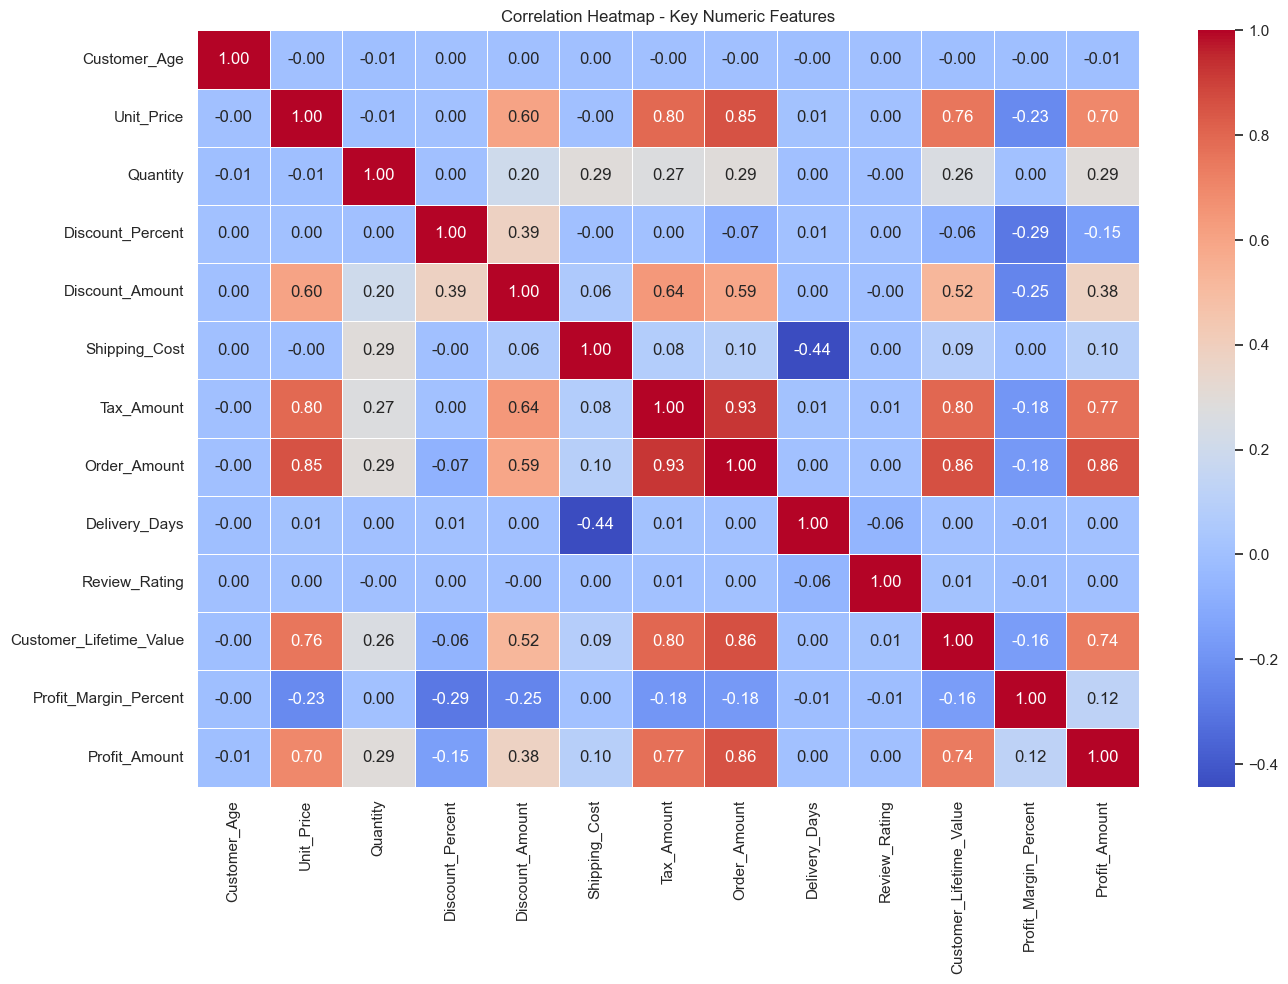

In [45]:
numeric_cols = ["Customer_Age", "Unit_Price", "Quantity", "Discount_Percent",
                 "Discount_Amount", "Shipping_Cost", "Tax_Amount", "Order_Amount",
                 "Delivery_Days", "Review_Rating", "Customer_Lifetime_Value",
                 "Profit_Margin_Percent", "Profit_Amount"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Key Numeric Features")
plt.tight_layout()
plt.show()

In [46]:
df[numeric_cols].corr()["Order_Amount"].sort_values(ascending=False)

Order_Amount               1.000000
Tax_Amount                 0.925680
Customer_Lifetime_Value    0.861991
Profit_Amount              0.856363
Unit_Price                 0.853489
Discount_Amount            0.591226
Quantity                   0.292821
Shipping_Cost              0.097538
Delivery_Days              0.004089
Review_Rating              0.003444
Customer_Age              -0.002299
Discount_Percent          -0.069630
Profit_Margin_Percent     -0.176849
Name: Order_Amount, dtype: float64

In [47]:
for col in ["Order_Amount", "Profit_Amount", "Customer_Lifetime_Value"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

Order_Amount: 3446 outliers (11.49%)
Profit_Amount: 2796 outliers (9.32%)
Customer_Lifetime_Value: 3261 outliers (10.87%)


In [48]:
if "df" not in globals():
    df = pd.read_csv("ecommerce_orders_dataset.csv")

top_country = df.groupby("Country")[col].sum().idxmax()
top_category = df.groupby("Product_Category")["Order_Amount"].sum().idxmax()
best_month = df.groupby("Month")["Order_Amount"].sum().idxmax()
overall_return_rate = (df["Returned"].eq("Yes").mean() * 100)
top_payment = df["Payment_Method"].value_counts().idxmax()
avg_clv = df["Customer_Lifetime_Value"].mean()
hv_rate = df["High_Value_Order"].eq("Yes").mean() * 100

print("KEY BUSINESS INSIGHTS")
print("=" * 50)
print(f"1. Highest revenue country         : {top_country}")
print(f"2. Best performing product category: {top_category}")
print(f"3. Best sales month                : Month {best_month}")
print(f"4. Overall return rate             : {overall_return_rate:.2f}%")
print(f"5. Most used payment method        : {top_payment}")
print(f"6. Average Customer Lifetime Value : {avg_clv:,.2f}")
print(f"7. % of High Value Orders          : {hv_rate:.2f}%")

KEY BUSINESS INSIGHTS
1. Highest revenue country         : United States
2. Best performing product category: Electronics
3. Best sales month                : Month 8
4. Overall return rate             : 10.11%
5. Most used payment method        : Credit Card
6. Average Customer Lifetime Value : 4,372.34
7. % of High Value Orders          : 25.00%
